# Monthly CN3S calibration — station 56696000

Calibrate MARIO DE CARVALHO with MERGE monthly areal rainfall and monthly mean Hydro discharge for 2019–2023. The station is identified by the ANA-style `ESTCODIGOADICIONAL` key. The run saves its configuration and quality under `/data/CN3S/stations/56696000/`. Repeated execution reuses prepared station inputs for the same dates. The first run requires live Hydro access and may prompt for Azure sign-in.

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from cn3s import StationCalibrationWorkflow
from hydrography import Hydrography, Stations


## Station and watershed

Use the same BHO network and telemetric source as the basin overview. The station must have exactly one usable watershed assignment.

In [8]:
station_code = "66010000"
start, end = "2000-01-01", "2026-08-01"
data_root = Path("/data/CN3S")
hydro_root = Path("/data/Geospatial_BR_Data/Hidrografia/BHO_2017_5k")


In [3]:

hydrography = Hydrography(
    watersheds_path=hydro_root / "geoft_bho_2017_5k_area_drenagem.parquet",
    reaches_path=hydro_root / "geoft_bho_2017_5k_trecho_drenagem.parquet",
)


In [4]:
stations = Stations(data_root / "Estacoes_Telemetricas.parquet", hydrography)
stations.assign_cobacia()
station = stations.stations.loc[station_code]
assert station["assignment_status"] == "assigned"
display(station[["ESTCODIGO", "ESTNOME", "cobacia", "dsversao", "assignment_status"]].to_frame("value"))
workflow = StationCalibrationWorkflow(stations, data_root=data_root)

,value
ESTCODIGO,150557110
ESTNOME,BARRA DO BUGRES
cobacia,8999411
dsversao,BHO bho_2017_v_01_05_5k de 2018-06-20
assignment_status,assigned


## Live input preparation and coverage

MERGE monthly rainfall is averaged over the upstream watershed. Hydro supplies daily `Vazao`, which the workflow aggregates to monthly means. Preparation caches both sources by station and date window; it requires Azure sign-in on the first Hydro request.

In [9]:
metadata = workflow.prepare_station(station_code, start, end, ("M",))

rain, discharge, metadata = workflow.load_station(station_code, "M")
observed = discharge.loc[start:end]
paired = pd.concat([rain, observed], axis=1).dropna()
coverage = pd.DataFrame(
    {
        "measure": ["rain months", "rain missing", "Hydro observed months", "paired months", "upstream area km²"],
        "value": [len(rain), int(rain.isna().sum()), int(observed.notna().sum()), len(paired), metadata["area_nuareacont_km2"]],
    }
)
display(coverage)
display(metadata)
assert len(rain) == len(pd.date_range(start, end, freq="MS"))
assert len(paired) >= 36, "Too few paired months for this demonstration"

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code FZWMGKZC9 to authenticate.


,measure,value
0,rain months,320.000000
1,rain missing,0.000000
2,Hydro observed months,315.000000
3,paired months,315.000000
4,upstream area km²,2263.638967


{'station_code': '66010000',
 'cobacia': '8999411',
 'network_version': 'BHO bho_2017_v_01_05_5k de 2018-06-20',
 'area_station_km2': None,
 'area_nuareacont_km2': 2263.6389673525478,
 'rain_periods': {'M': {'start': '2000-01-01', 'end': '2026-08-01'}},
 'input_revisions': {'M': '3d876e87d1014acd81dbab6134e5ae41'},
 'rain_source': 'MERGE',
 'discharge_source': 'Hydro Vazao'}

## Fit and saved configuration

The objective is Plain NSE with a chronological 80/20 training/test split. The random seed fixes the differential evolution run. `converged` reports SciPy termination separately from the quality scores.

In [10]:
optimizer_options = {"seed": 42, "maxiter": 60, "popsize": 8, "polish": True, "workers": -1, "disp": False}
summary = workflow.calibrate_station(
    station_code, "M", warmup_steps=3, train_ratio=0.8, max_act=3,
    objective="PlainNSE", optimizer_options=optimizer_options,
)
calibration_dir = workflow.station_dir(station_code) / "calibration" / "M"
assert json.loads((calibration_dir / "summary.json").read_text()) == summary
display(pd.Series({k: summary[k] for k in ("station_code", "frequency", "objective", "rain_period", "train_ratio", "warmup_steps", "max_act", "optimizer_options", "converged", "split_date", "train_count", "test_count", "train_nse", "test_nse")}, name="value").to_frame())
display(pd.Series(summary["params"], name="fitted value").to_frame())

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 0.6793 - [896.26, 6.5, 0.29, 0.09, 0.02, 0.8, 0.04, 0.0]
2 - Train objective: 0.5431 - [933.14, 20.49, 0.33, 0.01, 0.1, 0.9, 0.16, 0.0]
3 - Train objective: 0.5431 - [933.14, 20.49, 0.33, 0.01, 0.1, 0.9, 0.16, 0.0]
4 - Train objective: 0.5431 - [933.14, 20.49, 0.33, 0.01, 0.1, 0.9, 0.16, 0.0]
5 - Train objective: 0.5431 - [933.14, 20.49, 0.33, 0.01, 0.1, 0.9, 0.16, 0.0]
6 - Train objective: 0.5253 - [507.43, 40.29, 0.12, 0.01, 0.78, 0.89, 0.09, 0.0]
7 - Train objective: 0.5253 - [507.43, 40.29, 0.12, 0.01, 0.78, 0.89, 0.09, 0.0]
8 - Train objective: 0.5253 - [507.43, 40.29, 0.12, 0.01, 0.78, 0.89, 0.09, 0.0]
9 - Train objective: 0.5114 - [659.23, 18.7, 0.47, 0.02, 0.26, 0.98, 0.2, 0.0]
10 - Train objective: 0.4917 - [335.02, 7.03, 0.35, 0.02, 0.29, 1.0, 0.33, 0.0]
11 - Train objective: 0.4917 - [335.02, 7.03, 0.35, 0.02, 0.29, 1.0, 0.33, 0.0]
12 - Train objective: 0.4917 - [335.02, 7.03, 0.35, 0.02, 0.29, 1.0, 0.33, 0.0]
13 - Train objective: 0.4917 - [335.02, 7.03

,value
station_code,66010000
frequency,M
objective,PlainNSE
rain_period,"{'start': '2000-01-01', 'end': '2026-08-01'}"
train_ratio,0.8
warmup_steps,3
max_act,3
optimizer_options,"{'maxiter': 60, 'workers': -1, 'disp': False, ..."
converged,False
split_date,2021-01-01


,fitted value
name,Station 66010000
area,2263.638967
r0,712.229687
cn_i,1.600598
alfa,0.410472
beta,0.010374
k0,0.955224
k1,1.0
k2,0.180081
act,0


In [10]:
rain

2000-01-01     87.681450
2000-02-01    155.239410
2000-03-01    177.489163
2000-04-01     56.329725
2000-05-01     13.464925
                 ...    
2023-08-01     10.133326
2023-09-01     27.812981
2023-10-01     39.978195
2023-11-01     68.062422
2023-12-01     94.956911
Freq: MS, Name: prec, Length: 288, dtype: float64

In [11]:
discharge

Data
1963-11-01    1015.589333
1963-12-01     960.402258
1964-01-01     968.245806
1964-02-01    1071.408621
1964-03-01    1222.863226
                 ...     
2025-11-01    1029.498667
2025-12-01     930.271613
2026-01-01    1022.052258
2026-02-01    1186.417143
2026-03-01    1255.638065
Freq: MS, Name: Vazao, Length: 749, dtype: float64

In [15]:
from cn3s.objectives import Objectives
from cn3s import CN3S, CN3SOptimizer, CN3SParams


In [18]:
params = CN3SParams(name="Teste", area=586884, warmup_steps=3)
model = CN3S(params, freq="M")


In [19]:
optim = CN3SOptimizer(
    prec=rain,
    observed_q=discharge,
    model=model,
    train_ratio=0.8,
    max_act=5,
    objective=Objectives.PlainNSE,
)

print(f"Aligned record: {len(optim.aligned)} time steps")
print(f"Train: {optim.train_idx} | Test: {len(optim.aligned) - optim.train_idx}")

Aligned record: 288 time steps
Train: 230 | Test: 58


In [21]:
optim.optimize(maxiter=100, tol=1e-4, disp=False, workers=-1, x0=None)

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 642.0281 - [129.66, 62.14, 0.54, 0.03, 0.03, 0.31, 0.6, 0.0]
2 - Train objective: 642.0281 - [129.66, 62.14, 0.54, 0.03, 0.03, 0.31, 0.6, 0.0]
3 - Train objective: 642.0281 - [129.66, 62.14, 0.54, 0.03, 0.03, 0.31, 0.6, 0.0]
4 - Train objective: 642.0281 - [129.66, 62.14, 0.54, 0.03, 0.03, 0.31, 0.6, 0.0]
5 - Train objective: 642.0281 - [129.66, 62.14, 0.54, 0.03, 0.03, 0.31, 0.6, 0.0]
6 - Train objective: 251.2123 - [146.5, 77.6, 0.65, 0.0, 0.14, 0.4, 0.26, 0.0]


Process ForkPoolWorker-7:
Process ForkPoolWorker-12:
Process ForkPoolWorker-8:
Process ForkPoolWorker-9:
Process ForkPoolWorker-10:



Optimization interrupted — best model so far is in `optim.model`.


## Calibration quality

The split date is derived from the same unshifted paired series used by the optimizer. The plot compares the saved modeled and observed monthly discharge in both periods.

,period,start,end,paired modeled months,NSE
0,training,2000-04-01,2020-12-01,249,0.611734
1,held-out test,2021-01-01,2026-03-01,63,0.777022


Optimizer generations saved: 60
Saved in: /data/CN3S/stations/66010000/calibration/M


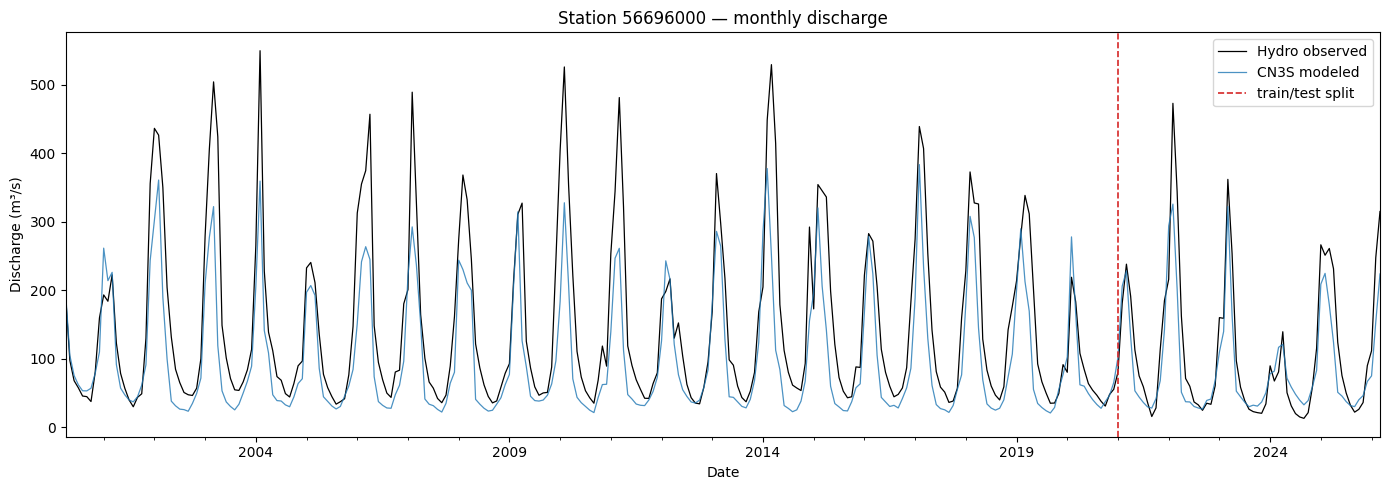

In [11]:
modeled = pd.read_parquet(calibration_dir / "modeled.parquet")
history = pd.read_parquet(calibration_dir / "history.parquet")
cutoff = pd.Timestamp(summary["split_date"])
quality = pd.DataFrame({
    "period": ["training", "held-out test"],
    "start": [modeled.index.min(), cutoff],
    "end": [cutoff - pd.offsets.MonthBegin(1), modeled.index.max()],
    "paired modeled months": [summary["train_count"], summary["test_count"]],
    "NSE": [summary["train_nse"], summary["test_nse"]],
})
display(quality)
print(f"Optimizer generations saved: {len(history)}")
print(f"Saved in: {calibration_dir}")
fig, ax = plt.subplots(figsize=(14, 5))
modeled["obs_q_m3s"].plot(ax=ax, label="Hydro observed", linewidth=0.9, color="black")
modeled["q_m3s"].plot(ax=ax, label="CN3S modeled", linewidth=0.9, color="tab:blue", alpha=0.8)
ax.axvline(cutoff, color="tab:red", linestyle="--", linewidth=1.2, label="train/test split")
ax.set(title="Station 56696000 — monthly discharge", xlabel="Date", ylabel="Discharge (m³/s)")
ax.legend()
fig.tight_layout()
plt.show()